### Analysis design:

#### Question 1:
What is happening to the experssion PPI network of each KO genes (UNG and RNASH2C)?

Hypothesis 1: they are differentially expressed between different coditions.
Hypothesis 2: they have some correlation with repair activity (?!)

#### Question 2:
Test 

### Tools: 
- [COBRApy](http://opencobra.github.io/) is a package for constraint-based modeling of biological networks written in Python.

- [python-igraph](https://igraph.org/python/) – The network analysis package
igraph is a collection of network analysis tools with the emphasis on efficiency, portability and ease of use. igraph is open source and free.

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt 
import stringdb

import utils

scanpy==1.7.1 anndata==0.7.5 umap==0.5.1 numpy==1.19.2 scipy==1.5.3 pandas==1.1.3 scikit-learn==0.24.1 statsmodels==0.12.2 python-igraph==0.8.3 leidenalg==0.8.3


In [2]:
mix15 = sc.read_h5ad('reanalyzed-data/mix15.h5ad.gz')
mix30 = sc.read_h5ad('reanalyzed-data/mix30.h5ad.gz')
mix60 = sc.read_h5ad('reanalyzed-data/mix60.h5ad.gz')

# PPI - protein protein interaction

https://github.com/gpp-rnd/stringdb

In [4]:
genes = ['UNG', 'RNASEH2C']
string_ids = stringdb.get_string_ids(genes)

In [5]:
string_ids

,queryItem,queryIndex,stringId,ncbiTaxonId,taxonName,preferredName,annotation
0,UNG,0,9606.ENSP00000242576,9606,Homo sapiens,UNG,Uracil-DNA glycosylase; Excises uracil residue...
1,RNASEH2C,1,9606.ENSP00000308193,9606,Homo sapiens,RNASEH2C,Ribonuclease H2 subunit C; Non catalytic subun...


In [6]:
interaction_partners_df = stringdb.get_interaction_partners(string_ids.queryItem).sort_values('score',ascending=False)

# network_df = stringdb.get_network(string_ids.queryItem)
# func_ann_df = stringdb.get_functional_annotation(string_ids.queryItem)

### UNG and RNASEH2C PPI 

Select top scored genes from `stringdb` database. 

In [40]:
UNG = interaction_partners_df.loc[interaction_partners_df.preferredName_A == 'UNG', ].reset_index(drop=True)
UNG_ppi = UNG.loc[UNG.score >= 0.9,'preferredName_B'].to_list()
UNG_ppi

['PCNA', 'DUT', 'DDB1', 'TYMS', 'APEX1', 'LIG1', 'OGG1']

In [46]:
RNASEH2C = interaction_partners_df.loc[interaction_partners_df.preferredName_A == 'RNASEH2C', ].reset_index(drop=True)
RNASEH2C_ppi = RNASEH2C.loc[RNASEH2C.score >= 0.7,'preferredName_B'].to_list()
RNASEH2C_ppi.remove('TREX1')
RNASEH2C_ppi

['RNASEH2A', 'RNASEH2B', 'CCNB2', 'CCNB1', 'SAMHD1']

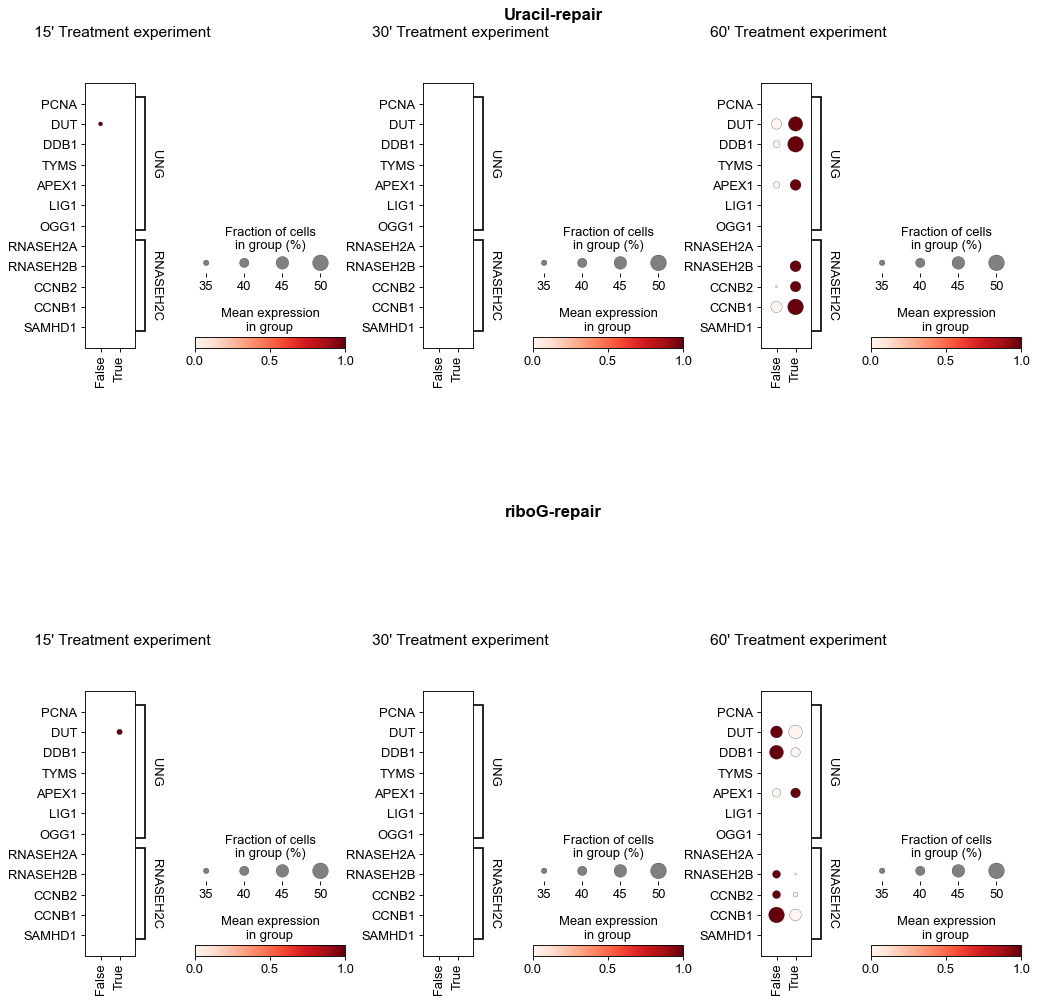

In [82]:
import matplotlib.pyplot as plt 
from matplotlib.gridspec import SubplotSpec

def create_subtitle(fig: plt.Figure, grid: SubplotSpec, title: str):
    "Sign sets of subplots with title"
    row = fig.add_subplot(grid)
    # the '\n' is important
    row.set_title(f'{title}\n', fontweight='semibold', fontsize=15)
    # hide subplot
    row.set_frame_on(False)
    row.axis('off')

rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15,15), gridspec_kw={'hspace':1,'wspace':0.3})

for i,adata in enumerate([mix15,mix30,mix60]):
    
    times = ['15','30','60']
    
    ppi_genes_dict = {'UNG': UNG_ppi,'RNASEH2C': RNASEH2C_ppi}
    
    for j, repair in enumerate(['Uracil-repair', 'riboG-repair']):
        ax_dict = sc.pl.dotplot(
            adata,ppi_genes_dict,title=f'{times[i]}\' Treatment experiment',
            dot_max=0.5, dot_min=0.3, standard_scale='var',swap_axes=True,
            groupby=repair,show=False,ax=axes[j,i]
        )
    
grid = plt.GridSpec(rows, cols)
create_subtitle(fig, grid[0, ::], 'Uracil-repair')
create_subtitle(fig, grid[1, ::], 'riboG-repair')

fig.set_facecolor('w')
fig.savefig('network-analysis/dotplot.pdf')
plt.show()

In [85]:
import IPython
print (IPython.sys_info())

{'commit_hash': '2486838d9',
 'commit_source': 'installation',
 'default_encoding': 'UTF-8',
 'ipython_path': '/Users/abearab/anaconda3/envs/sc-analysis/lib/python3.6/site-packages/IPython',
 'ipython_version': '7.16.1',
 'os_name': 'posix',
 'platform': 'Darwin-19.6.0-x86_64-i386-64bit',
 'sys_executable': '/Users/abearab/anaconda3/envs/sc-analysis/bin/python',
 'sys_platform': 'darwin',
 'sys_version': '3.6.13 |Anaconda, Inc.| (default, Feb 23 2021, 12:58:59) \n'
                '[GCC Clang 10.0.0 ]'}
